# Import

In [11]:
import tomllib
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_openai import ChatOpenAI
from IPython.display import Image

## Creating LLM Object

In [7]:
# Loading secrets to get API key
with open("../secrets.toml", "rb") as f:
    secrets = tomllib.load(f)

# Creating the LLM instance with the API key
llm = ChatOpenAI(model="gpt-4o", api_key=secrets["api_keys"]["openai"])

Note:

Message chains can get quite long and end up; eating away a lot of tokens as the conversation drags on. To prevent this, we can filter/trim the messages.

We can do this in one of two ways:
1. Removing older messages from the state
2. Sending only the recent messages to the llm

_To search for a potential 3rd option: Archiving message chains and using them for RAG?_

# Part 0: Default Graph Flow

Here, we recap how a call to a graph affects the graph state

In [4]:
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot"),
            HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance")]

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


In [10]:
# Testing the LLM instance
response = llm.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

Aside from whales, there are several other fascinating ocean mammals you might want to explore:

1. **Dolphins**: Intelligent and social creatures known for their playful behavior and often found in group pods.

2. **Porpoises**: Often confused with dolphins, porpoises are generally smaller and have different facial structures and teeth.

3. **Seals**: Pinnipeds with semi-aquatic lifestyles, seals are adept swimmers but often come ashore to rest and breed.

4. **Sea Lions**: Similar to seals, sea lions are more social and can "walk" on land using their large front flippers.

5. **Walruses**: Distinctive for their large tusks and whiskers, walruses are found in the Arctic and are keystone species in their habitats.

6. **Manatees**: Also known as "sea cows," manatees are gentle herbivores primarily found in warm coastal areas and rivers.

7. **Dugongs**: Similar to manatees, dugongs are marine mammals that

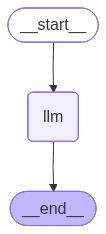

In [25]:
# Creating a node to invoke an llm with messages as input
def call_llm(state):
    return {"messages": llm.invoke(state["messages"])}
    

# Creating a graph to invoke the messages
builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_edge(START, "llm")
builder.add_edge("llm", END)
graph = builder.compile()

Image(graph.get_graph().draw_mermaid_png())

In [28]:
# Testing the graph
messages = graph.invoke({"messages": messages})

for m in messages["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are several fascinating ocean mammals you might want to learn about besides whales. Here are a few:

1. **Dolphins**: Highly intelligent and social creatures known for their playful behavior. There are various species, including the well-known bottlenose dolphin and the orca (or killer whale), which is actually the largest member of the dolphin family.

2. **Porpoises**: Similar to dolphins but generally smaller and with different dental and physical characteristics. The harbor porpoise and the vaquita are examples.

3. **Seals**: These are pinnipeds, which also include sea lions and walruses. Seals are kno

# Part 1: Removing Older Messages
Here, we can use a Reducer to remove all but the most recent messages in the State.

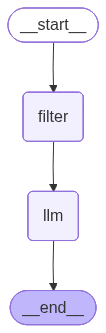

In [34]:
def filter_messages(state):
    return {"messages": state["messages"][-2:]}  # Keep only the last 2 messages

def call_llm(state):
    print("State at llm node: ", state)  # Debugging statement to check the state
    return {"messages": llm.invoke(state["messages"])}

# Creating a graph to invoke the messages after filtering them
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("llm", call_llm)
builder.add_edge(START, "filter")
builder.add_edge("filter", "llm")
builder.add_edge("llm", END)
graph = builder.compile()

Image(graph.get_graph().draw_mermaid_png())

In [35]:
messages2 = [AIMessage(f"Hi, how can I help you?", name="Bot"),
             HumanMessage(f"I want to learn about maths", name="Lance"),
             AIMessage(f"Sure, what topic in maths are you interested in?", name="Bot"),
             HumanMessage(f"I want to learn about algebra", name="Lance")]

In [36]:
# Testing this graph
response = graph.invoke({"messages": messages2})
for m in response["messages"]:
    m.pretty_print()

State at llm node:  {'messages': [AIMessage(content='Hi, how can I help you?', additional_kwargs={}, response_metadata={}, name='Bot', id='72ef43a0-c980-4677-bfcb-464178e9421b', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='I want to learn about maths', additional_kwargs={}, response_metadata={}, name='Lance', id='a54ee132-bcc0-46a9-b448-77a4dc4fae8b'), AIMessage(content='Sure, what topic in maths are you interested in?', additional_kwargs={}, response_metadata={}, name='Bot', id='6f736530-0a39-41af-ac2f-988c47caaf8e', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='I want to learn about algebra', additional_kwargs={}, response_metadata={}, name='Lance', id='7ea9e195-dcda-4508-8ceb-64c61461b669')]}
================================== Ai Message ==================================
Name: Bot

Hi, how can I help you?
================================ Human Message =================================
Name: Lance

I want to learn about maths
==========================

# Part 2: Limiting Messages to LLM